## Dimensionality Reduction.

In this lesson we try to understand a concept called *Dimensionality Reduction*, and learn ways to implement such dynamic.

First of all let's get into what do we mean by the word **dimension**:
+ By **dimension** we mean the number of features that each of our data samples have, And when we say a Data is high dimensional we mean that it has many features, and vice versa.

Now why **Dimension Reduction**? Why can't we work with the data and their original features they have?
+ In ML, dimensions (or features) are the predictor variables that determine a model's output. They may also be called input variables. High-dimensional data denotes any dataset with a large number of predictor variable. Such datasets can frequently appear in **biostatistics**, as well as **social science observational studies**, where the number of data points(that is, observations) **outweights** the number of predictor variable. High-dimensional datasets pose a number of practical concerns for ML algorithms, such as **increase computation time**, **Storage space for big data**, and so on. But the **biggest** concern is perhaps **decreased accuracy in predictive models**. Statistical and ML models trained on high-dimensional datasets often **generalize poorly**


**The Curse of Dimensionality**:<br>

+ There is an inverse relationship between increasing model dimensions and decreasing generalizability. As the number of model input variables increase, the **model's space increase**. If the number of data points **remains the same**, however, the data becomes **sparse**. This means the **majority** of the model's feature space is **empty**, that is, without observable data points. As data sparsity increase, data points become so **dissimilar** that predictive models become less effective at identifying explanatory patters. And the fun part is in order to adequately explain patterns in sparse data, models may **overfit** on training data. It is because of that we say increase in dimensionality can lead to poor generalization.<br> Collecting more data can reduce data **sparsity** and thereby the curse of dimensionality, and data should increase exponentially as the dimension increases. Although collecting sufficient data is, of course, not always feasible.

<br>

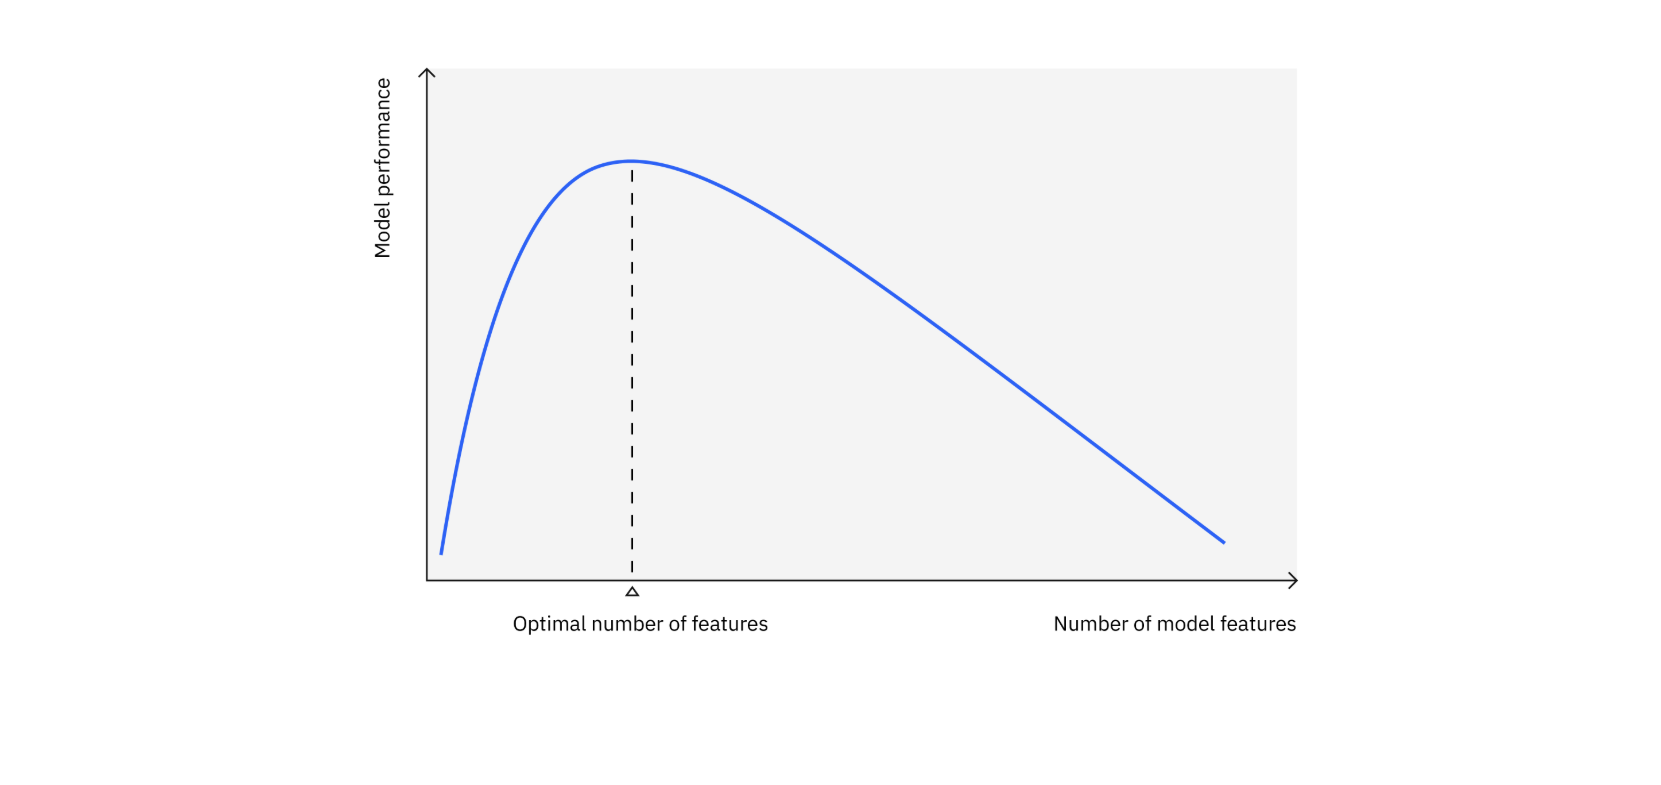
<center>Figure 1: Effect of number of features on model's performance, Adopted from [2]</center>
<br>

#### Dimensionality Reduction Benefits:

+ **Visualization**: It can *project* high-dimensional data into 2D or 3D.
+ **Helps avoid overfitting**: When the number of parameters doesn't match number of data samples, overfitting may happen and by dimensionality reduction which leads to the reduction in number of parameters it can be avoided. We can reduce **noise** by reducing features, and improve accuracy by reducing noise.
+ **More efficient use of resources**: There will be a more efficien tuse of Time, memory, CPU and any other involved resource after reducing dimensionality.

> One of the most important benefits of dimensionality reduction  is for **data visusalization** because we cannot visualize a data in 100x dimension and to be able to comprehend it we should reduce it to 1D, 2D and 3D dimensions.

There are two techniques for reduction: 
+ **Feature Selection**: It only selects a asubset from a given features set. The problem with this is that it loses influence of many features along side this selection, and it is not very prefarable.
+ **Feature Extraction**: From all of the dimensions we choose *N* dimensions but this *N* dimensions are derived from all of our features. A linear or non-linear transform from the original feature space to a lower dimension space:

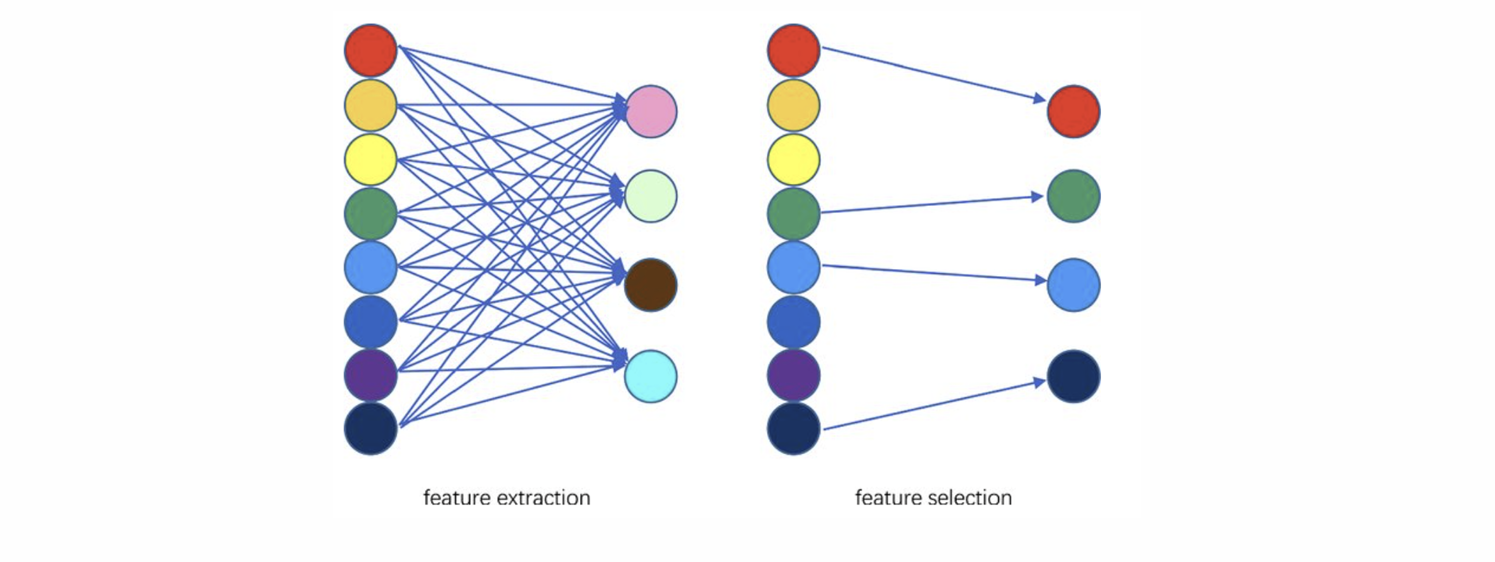
<center>Figure 2: Visualization of two reduction methods, Adopted from [1]</center>
<br>

In the feature extraction method we have something like:
$$\hat{x}_1 = w_{1,1}x_1 + ... + w_{10,1} \\ ........ \\ \hat{x}_4 = w_{1,10}x_1 + ... + w_{10,10}$$
$$\begin{pmatrix} w_{1,1} & ... & w_{10,1} \\ ... & ... & ... \\ w_{1,10} & ... & w_{10,10} \end{pmatrix} \times \begin{pmatrix} x_1 \\ ... \\ x_{10} \end{pmatrix} = \begin{pmatrix} \hat{x}_1 \\ ... \\ \hat{x}_4 \end{pmatrix}$$

We've been introduced to the problem and the way of solving it. Now we want to make our problem a **optimization** problem, And the question raises here, is that, what should we *optimize* here?

+ Our goal is to **maximize** retention of **important information** while reducing dimensionality. 

**Important information**:
+ **Variance**(spread of data): The core idea is that dimensions along which data **varies the most** are the most informative. If data points are clustered very tightly along a particular direction, the direction doesn't tell us much about the differences between data points. Conversely, if data points are widely spread along a direction, that direction captures significant differences and patterns within the data.

+ **Distinguishing Features/Differences**: Important information helps us differentiate between data points. If a feature (dimension) has high variance, it means its values differ significantly across various data instances. These differences are often what allows us to classify, cluster, or understand the underlying structure of data.

+ **Signal vs Noise**: High variance is often associated with the "signal" in the data, while low variance can be considered "noise" or redundant information. By retaining dimensions with high variance, we aim to keep the meaningful patterns and discard the less informative ones.


For example when we wanna reduce an *n*(2) dimensional space to a *d*(1) dimensional space, we wanna have the maximum variance in the projected data points:

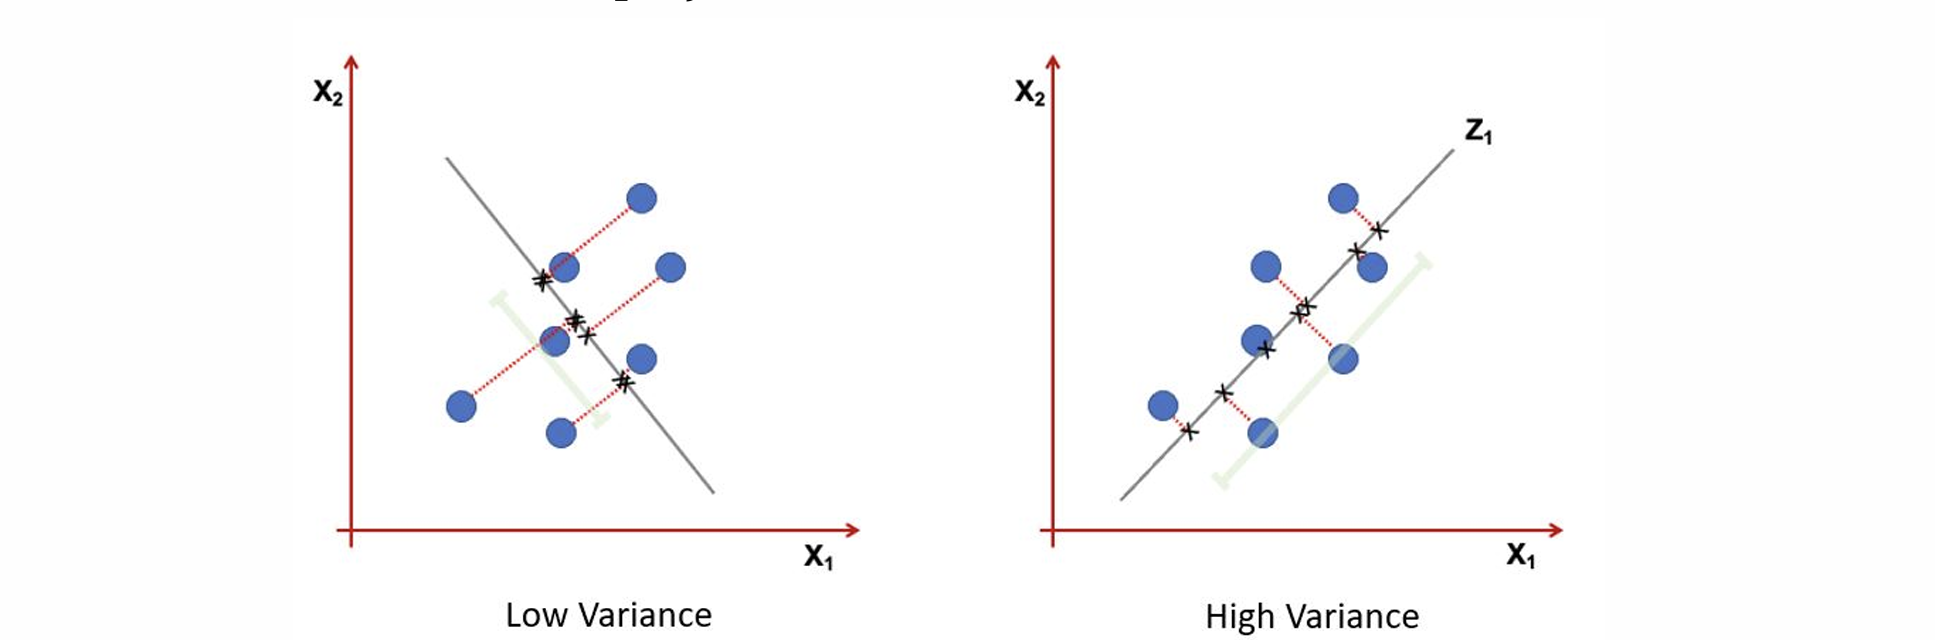
<center>Figure 3: Variance in data projection, Adopte from [1]</center>

### PCA

PCA is the most common dimensionality reduction method. It converts a set of **correlated** featured in the high dimensional space into a series of **uncorralated** features in the low dimensional space. These **uncorollated** features are also called **prinicipal components**
<br>

PCA is an **orthogonal linear transformation** which means that all the principal components are prependicular to each other.

+ **Goal**: Is the have the maximum variance after data's projection on the new feature. And in particular, we choose projection that minimizes the squared error in reconstructing the original data.

$$\text{Suppose } X = \begin{pmatrix} X_1^T \\ . \\ . \\ . \\ X_N^T\end{pmatrix}_{N \times d} = \begin{pmatrix} x_{11} & x_{12} & ... & x_{1d} \\x_{21} & x_{22} & ... & x_{2d} \\ ... & ... & ... & ... \\ x_{N1} & x_{N2} & ... & x_{Nd} \end{pmatrix}$$

Now we want to multiply matrix $X_{N \times d}$ to a vector of principle components $V_{d \times k}$ to get a new sample-feature matrix $\tilde{X}_{N \times k}$, we reduced the dimensionality of our samples from a *d* dimensional space to a *k* dimensional space. 

+ **Goal**: Find a $V$ such that when get multiplied with $X$ to project data sammples into new feature set, we see a maximum variance across data on the new space.    

+ We would assume that data is **mean-centered**, which is: $\mu_x = \frac{1}{N} \sum_{i=1}^{N} X_i = 0_{d \times 1}$
    + We scaled our data in a way that the mean of each feature equals to zero, and the reason that we done that was because of the variance equation that we're gonna see much more about it in the following sections, but for just an overview: 
    $$Var(x) = E[x^2] - \underbrace{(E[x])^2}_{0}$$
    And we did that to make the second term of the equation above zero.

To have a better visualization and intuition of what this projection of data means look at the following figures:

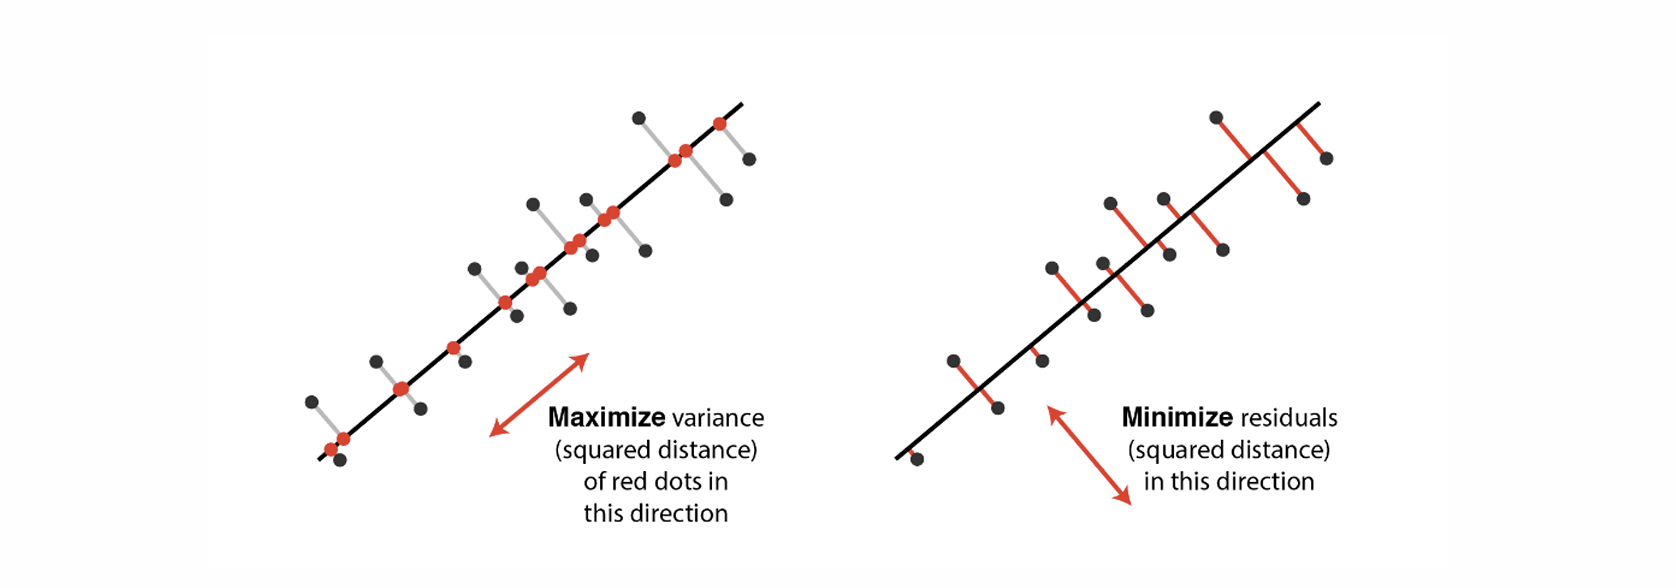
<center>Figure 4: Orthogonal projection of the data onto a lower-dimensional linear subspace, Adpted from [1]</center>

In the above figure you see that we have obtained a new principal component(new feature) and projected the data from previous space to a subspace created by feature extraction.

If you look at the figure you see that there are two propositions:
+ **Maximize** variance
+ **Minimize** residuals

And these are theoritically the same in the optimization concept in the dimensionality reduction using PCA. But How?


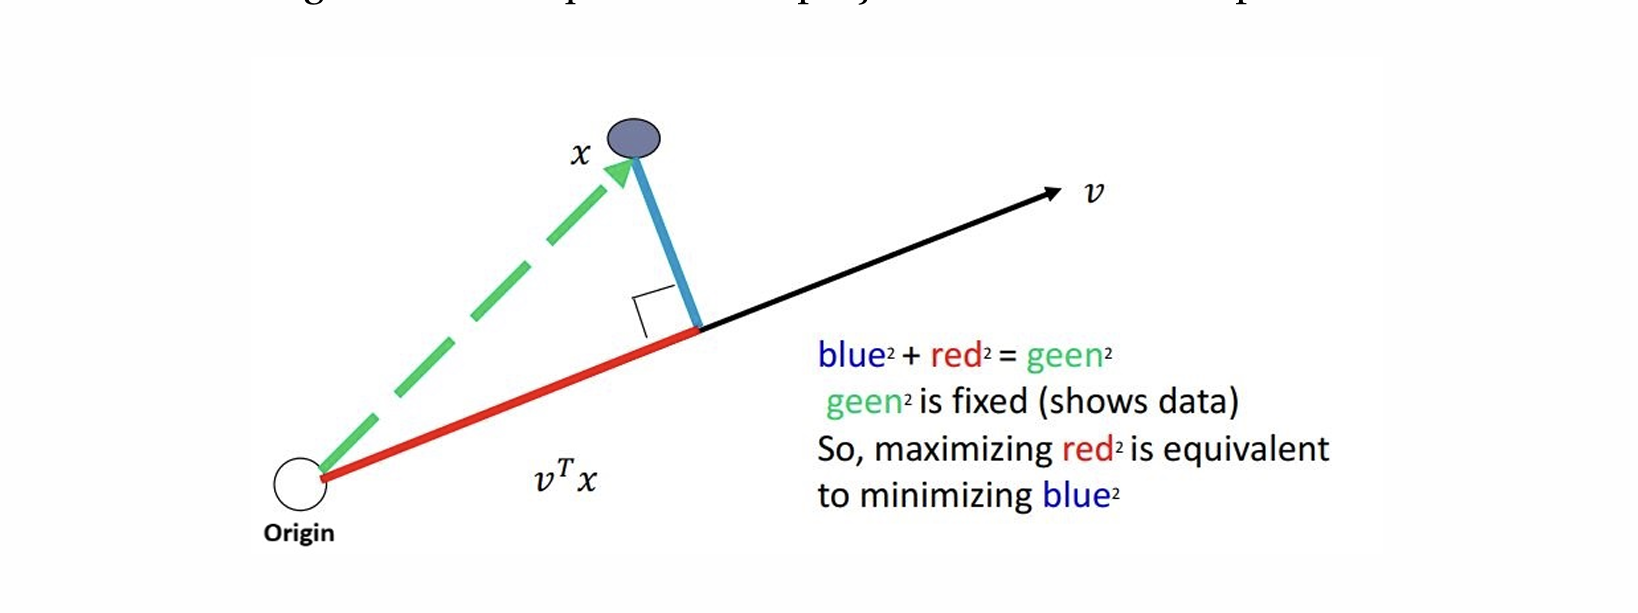
<center>Figure 5: maximizing variance and minimizing residuals effect on optimality of the new feature, Adopted from [1]</center>

We conclude from the figure above that, **Minimizing** the sum of square distances to the subspace (residuals) is **equivalent** to **maximizing** the sum of squares of the projection on that subspace(variance).

### Principal Components(PCs):<br>
A set of **orthonormal** vectors ($v = [v_1, v_2, ..., v_k]$)(where each $v_i$ is $d \times 1$), generated by PCA, which fulfill both the interprations.

> An important thing to remind yourself is the fact of each vector $v$ has $d$ rows, which is concluded from the feature extraction concept of PCA. Each $v$ is a new feature which has derived from the weighted sum of all of the previuos features.

Now we wanna maximize the variance of the projected data on the new features$:

+ Projection of data points on $v_1$ (PC1):

$$\Pi = \Pi_{v_1} \{X_1, ..., X_N\} = \{v_1^TX_1, ..., v_1^TX_N\}$$

Now we wanna maixmize the variaance of the projection above (We have mean-centered our features.):

$$Var(X) = E[X^2] - \underbrace{E[X]^2}_{0}$$
$$Var(\Pi) = \frac{1}{N}(\sum_{i = 1}^{N} (v_1^TX_i)^2)$$

> We are looking for a $v_1$ that maximize the variance above

> We have other constraints for $v_1$, along the vector $v_1$ we can have other vectors which are similar to the $v_1$ itself, so we may have infinite answer for a principal component.

**About the statement above:**
+ a **principal component vector $v_1$** is a **direction** in space
+ But any non-zero scalar multiple of $v_1$, like $2v_1$, $-v_1$, $0.5v_1$, etc., points in the **same direction** or the **opposite direction**.
+ So **infinitely many vectors** lie along the same line through the origin, which are all valid as principal component vectors. 

> In PCA, we only care for **direction**, not the magnitude or sign, so $v_1$ and $-v_1$ represent the same principal component. 

> And the prroblem above accurs when solving eigenvector problem in PCA (explained later).

Now for fixing these problems we apply two common **constraints** in PCA: 
1. **Unit length**:

    $$||v|| = 1$$

    This picks only one vector from the infinite line.

2. **Fixed Direction**(optional):

    Sometimes people fix the **sign convention** so that the **largest absolute value** in the vector is positive(to be consistent across runs.)

$$v_1 = \argmax_{v_1} \frac{1}{N} (\sum_{i=1}^{N} (v_1^TX_i)^2): \;\;\;\; ||v_1|| = 1$$

> If we didn't use the constraing, the optimization problem above would not converge and would not give a proper answer.

We've seen that for easier calculations we sometimes manipulate our data in a way that does not effect the final result, as an example of this manipulation we can refer to **Standardization** or **Z-Score normalization**.

**Standardization/ Z-Score normalization** includes:
1. **Mean-centering** each feature => mean becomes 0
2. **Scaling** each feature to have **unit variance** => variance becomes 1

Previously we etalked about the mean-centering and we saw why we did it, now we wanna get into **Scaling**.

First of all let's see what it does:

Given a dataset $X \in R^{n \times d}$:<br>
For each feature (column) $j$, compute:

+ Mean: $\mu_j = \frac{1}{n} \sum_{i=1}^{n} X_{ij}$
+ Standardization deviation: $\sigma_j = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (X_{ij} - \mu_j)^2}$

And then standardize:

$$Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}$$

> In the formula above both mean-centered and scaling happened at the same time. And the result is that each feature (column in $Z$) has **mean = 0, variance = 1**.


Why do we standardize:
1. **Equal importance to all features**: Feature with large ranges can dominate those with smaller ranges. Standardizing removes this bias.
2. **Improves Performance** of many algorithms: Algorithms that rely on distance or directions (like PCA, k-means, SVM, logistic regression) often perform **much better** on standardize data.
3. **Numerical Stability**: Especially for eigenvalue/eigenvector problems (like in PCA), standardization improves conditioning and convergence.


> Scaling can be both good and bad, take a scenario that two data sample that are far from each other and have not so much thing to od with each other, after scaling they get closer together.

As in PCA, it finds principal components (directions) that captures the most variance in the data. If one feature has  much higher variance than others, PCA will be biased toward that feature.

Before getting to know PCA algorithm we need to know the following mathematical concepts:
+ Eigenvalus or Eigenvectors
+ Sample covariance matrix
+ Lagrangian multiplier

### Eigenvalues and Eigenvectors

When a matrix *A* multiplies to a vector *V* it's equivalent to rotating or scaling that vector. Long storey short using a projection we take our vector to a new space. And for each value of *A*, If we observe that the vectors do not get rotated and when get multiply to *A* they just get **scale**, which means they get smaller or bigger only in that direction, We call these *V* vectors **Eigenvectors**, and the amount of their scaling would be **Eigenvalues**.

+ **Eigenvector**: A **non-zero** vector that multiplies only by a **scalar factor** when a **linear transformation** is applied.

+ **Eigenvalue**: The scalar factor by which the eigenvector is scaled. 

$$Av = \lambda v$$

Where: 
+ $A$: is a square matrix
+ $v$: Eigenvector
+ $\lambda$: Eigenvalue

**How to find Eigenvalues and Eigenvectors**:
$$Av = \lambda v$$
$$Av - \lambda v = 0$$
$$(A - \lambda I)v = 0$$

$v$ cannot be zero, so:

$$det(A - \lambda I) = 0$$

We solve it for $\lambda$ and the substitue $\lambda$ back into the equation $Av = \lambda v$ to find $v$.

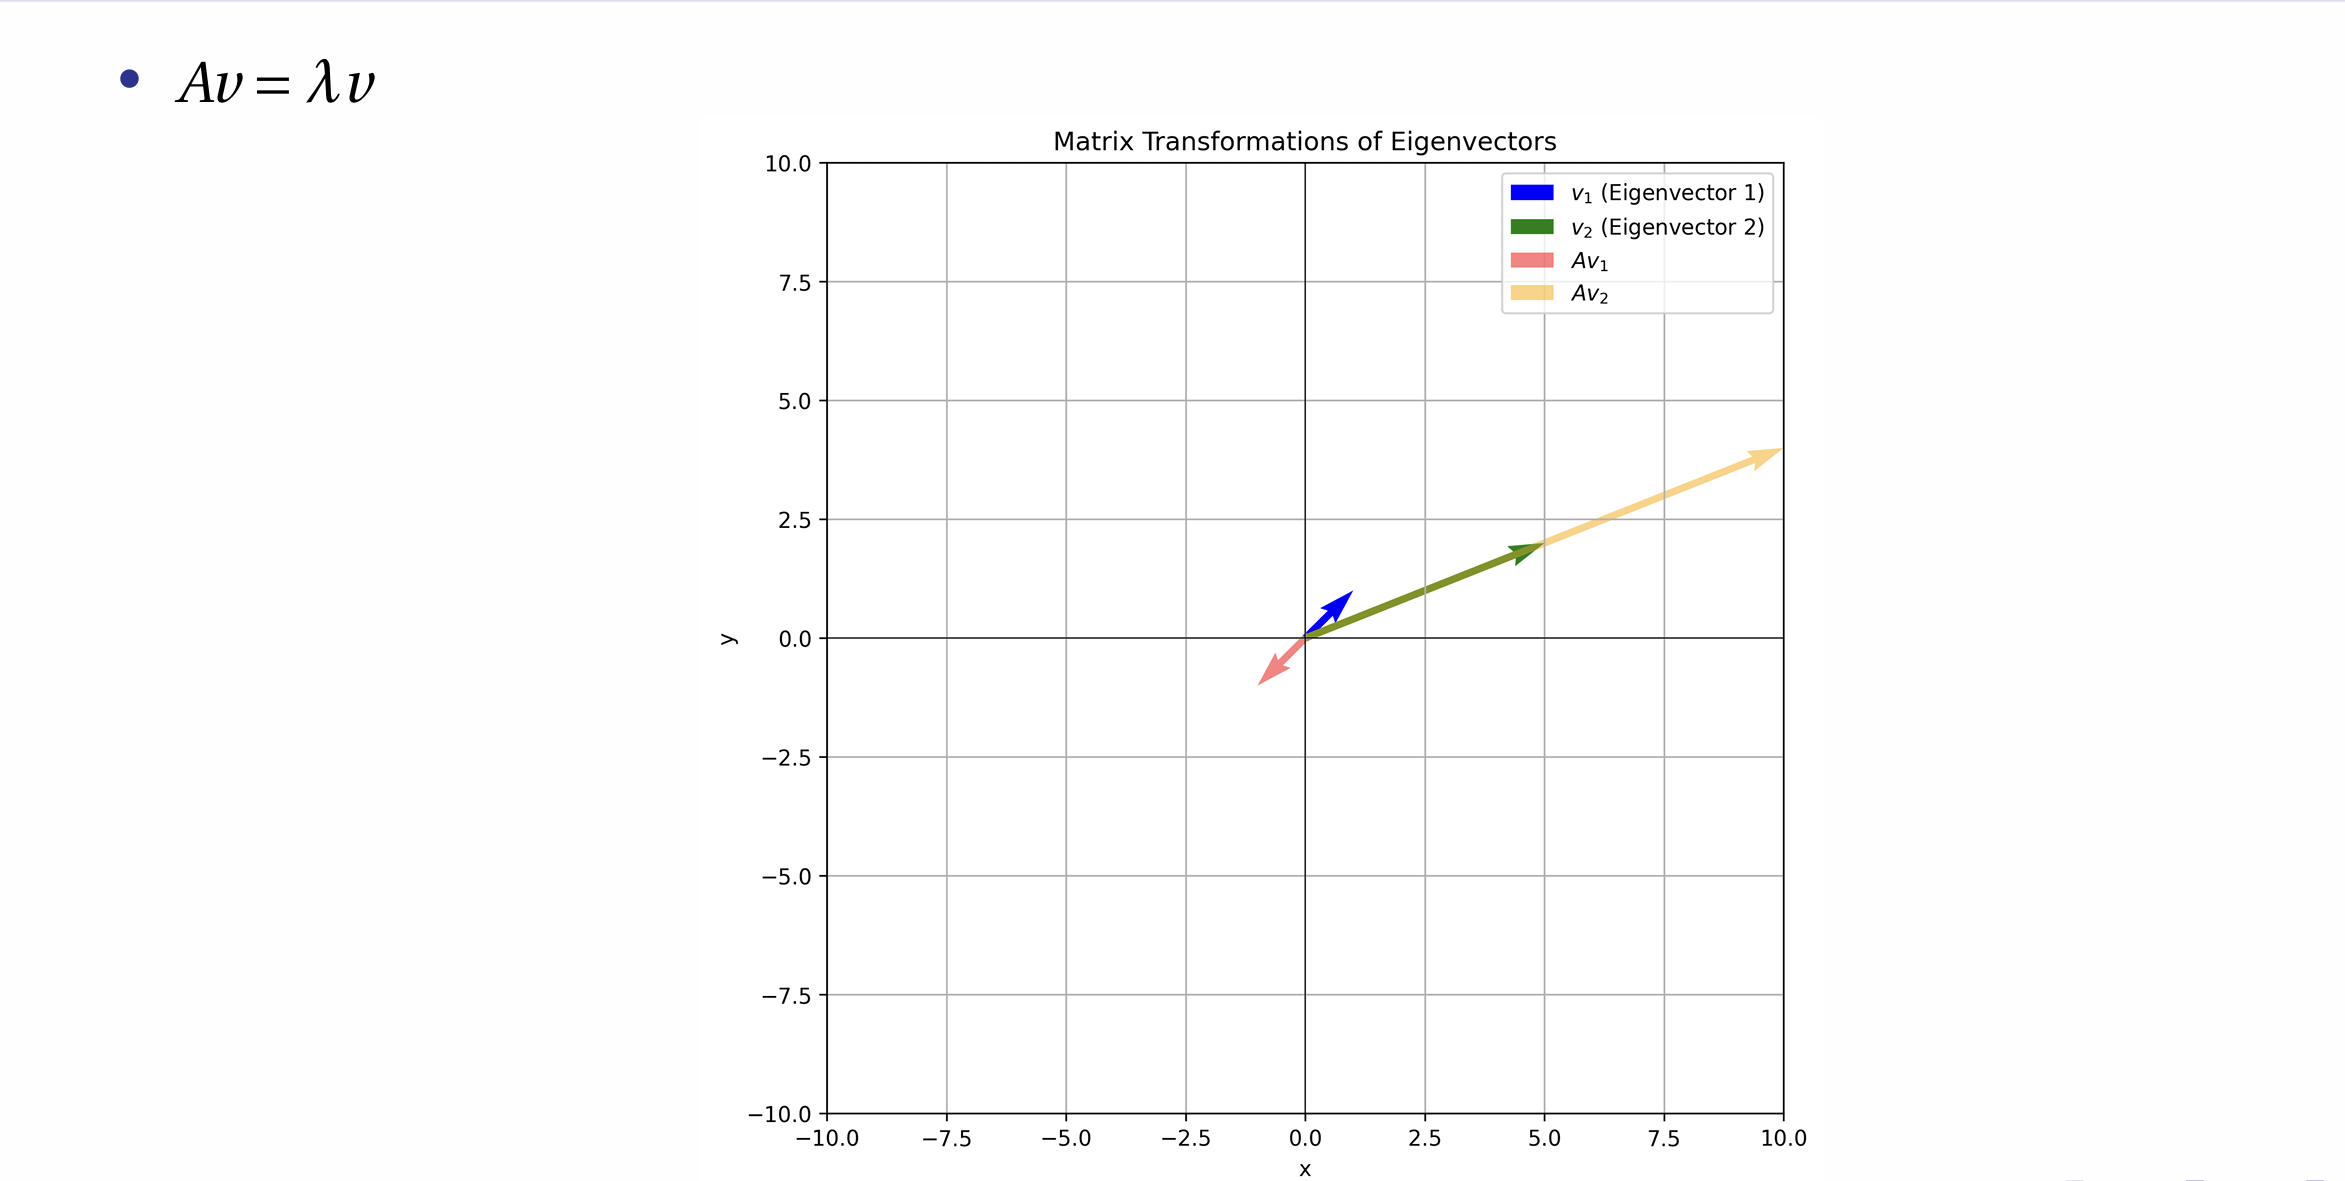
<center>Figure 6: Matrix Transformation of Eigenvectors, Adopted from [1]</center>



### Covariance

The degree of linear dependence of two random variables can be found from their covariance or correlation.<br>
Covariance is a measure of how much two random features vary together.

$$Cov(X, Y) = E[(X - E[X])(Y - E[Y])] = E[(Y - E[Y])(X - E[X])] = Cov(X, Y) = Cov(Y, X)$$

+ $Cov(X, Y) > 0 \rightarrow$ The more we increase X, the more Y increases.
+ $Cov(X, Y) < 0 \rightarrow$ X and Y have an inverse relation with each other, the more we increase X the value of Y decrease and the other way around.

> Covariance is symmetric

### Covariance Matrix<br>
A covariance matrix generalizes the concept of covariance to muliple features.<br>
For a random vector $F = [F_1, F_2, ..., F_d]$:
$$\Sigma = \begin{pmatrix} Var(F_1) & Cov(F_1, F_2) & ... & Cov(F_1, F_d) \\ Cov(F_2, F_1) & Var(F_2) & ... & Cov(F_2, F_d) \\ ... & ... & ... & ... \\ Cov(F_d, F_1) & Cov(F_d, F_2) & ... & Var(F_d) \end{pmatrix}$$


> By nowing that covariance is symmetric: $Cov(X, Y) = Cov(Y, X)$ we can see that in the matrxi above the below equality stays:
$$\Sigma{ij} = \Sigma{ji}$$

Some Examples:

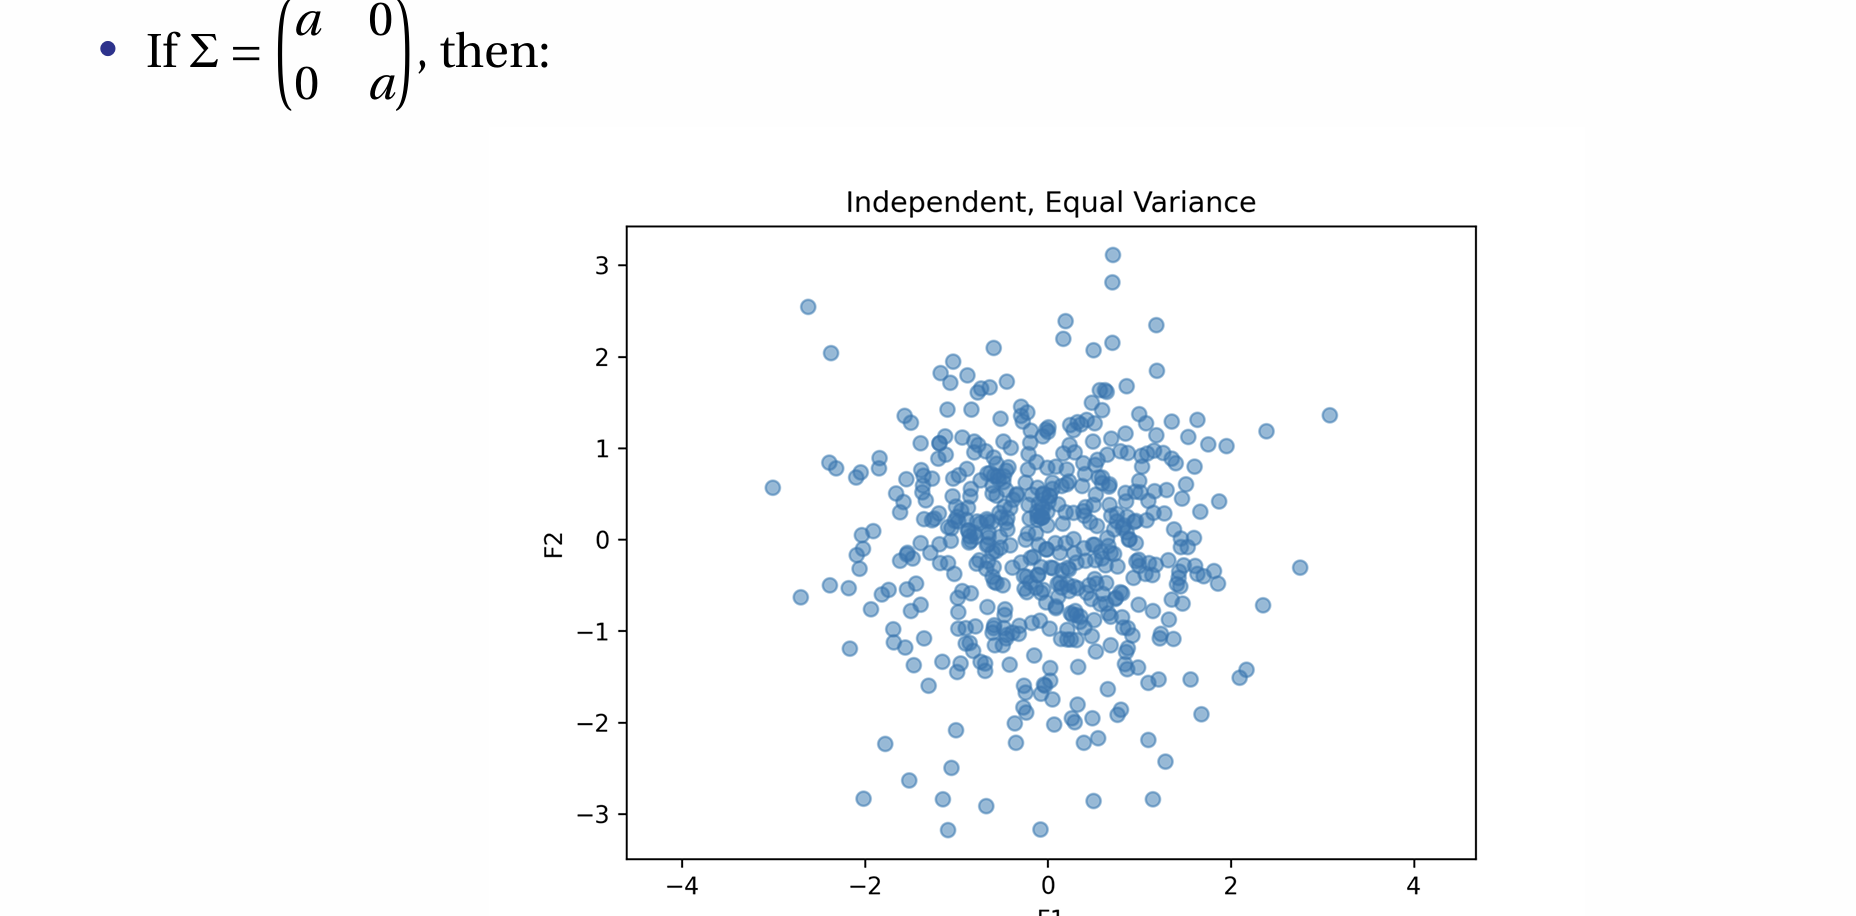
<center>Figure 7: Independent, Equal Variance, Adopted from [1]</center>
<br>

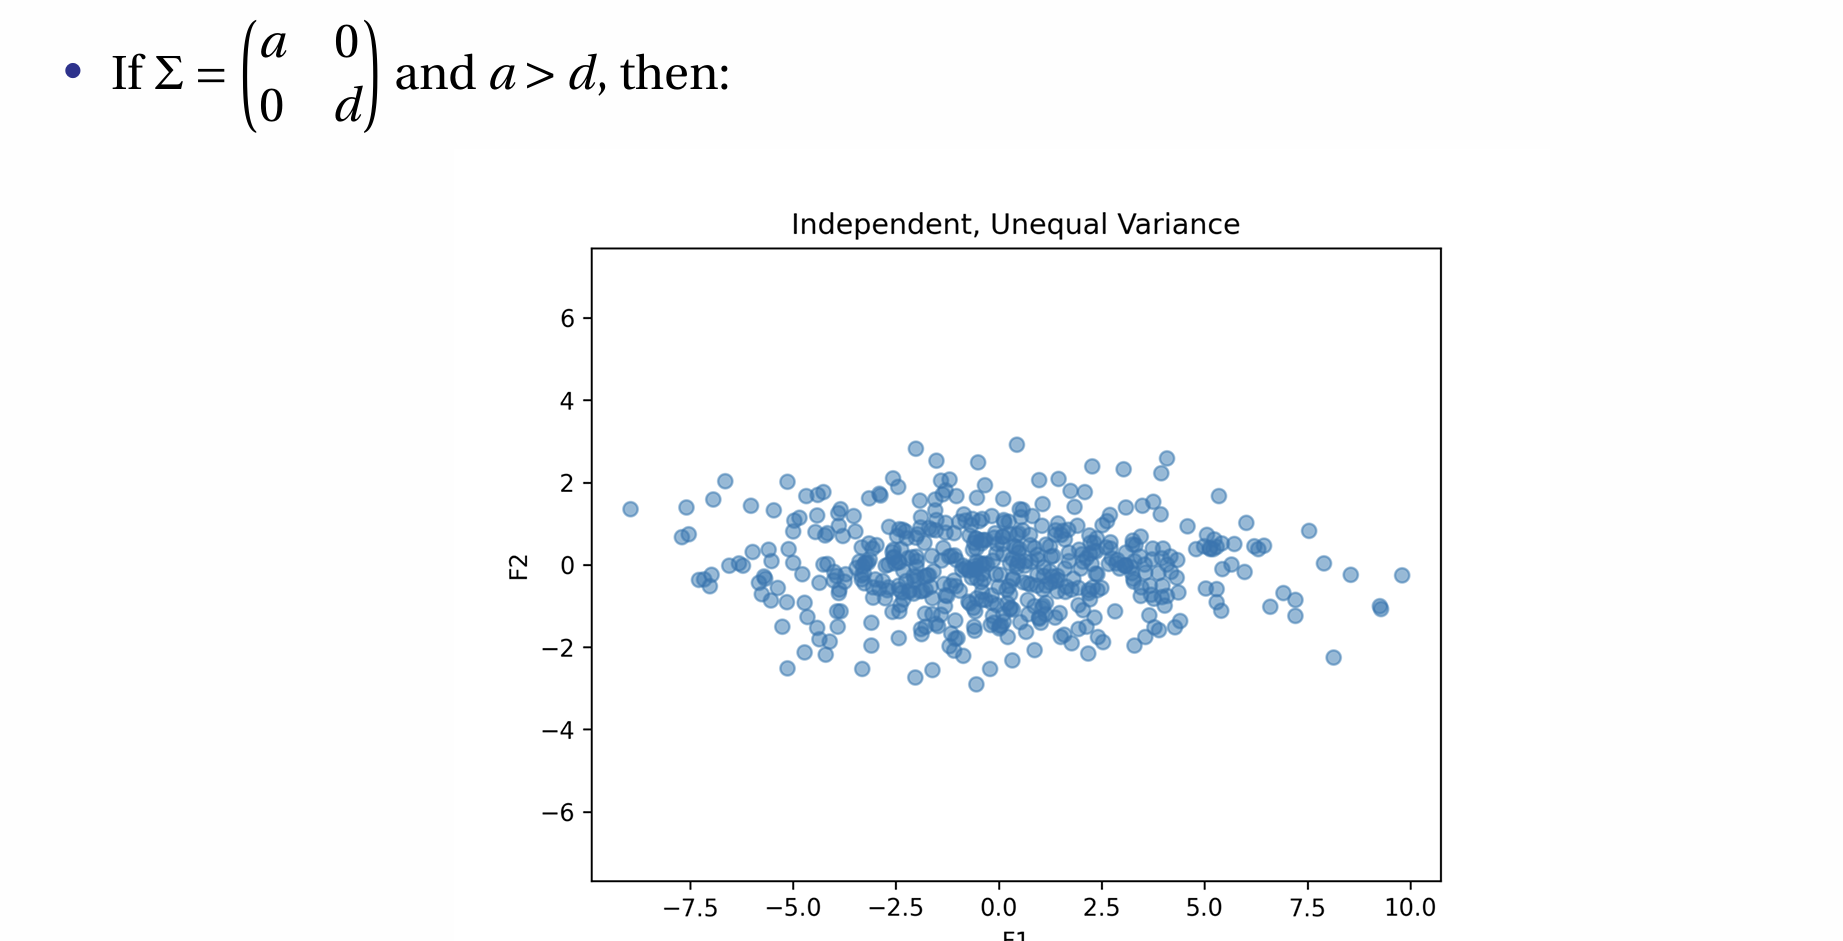
<center>Figure 8: Independent, Unequal Variance, Adopted from [1]</center>
<br>

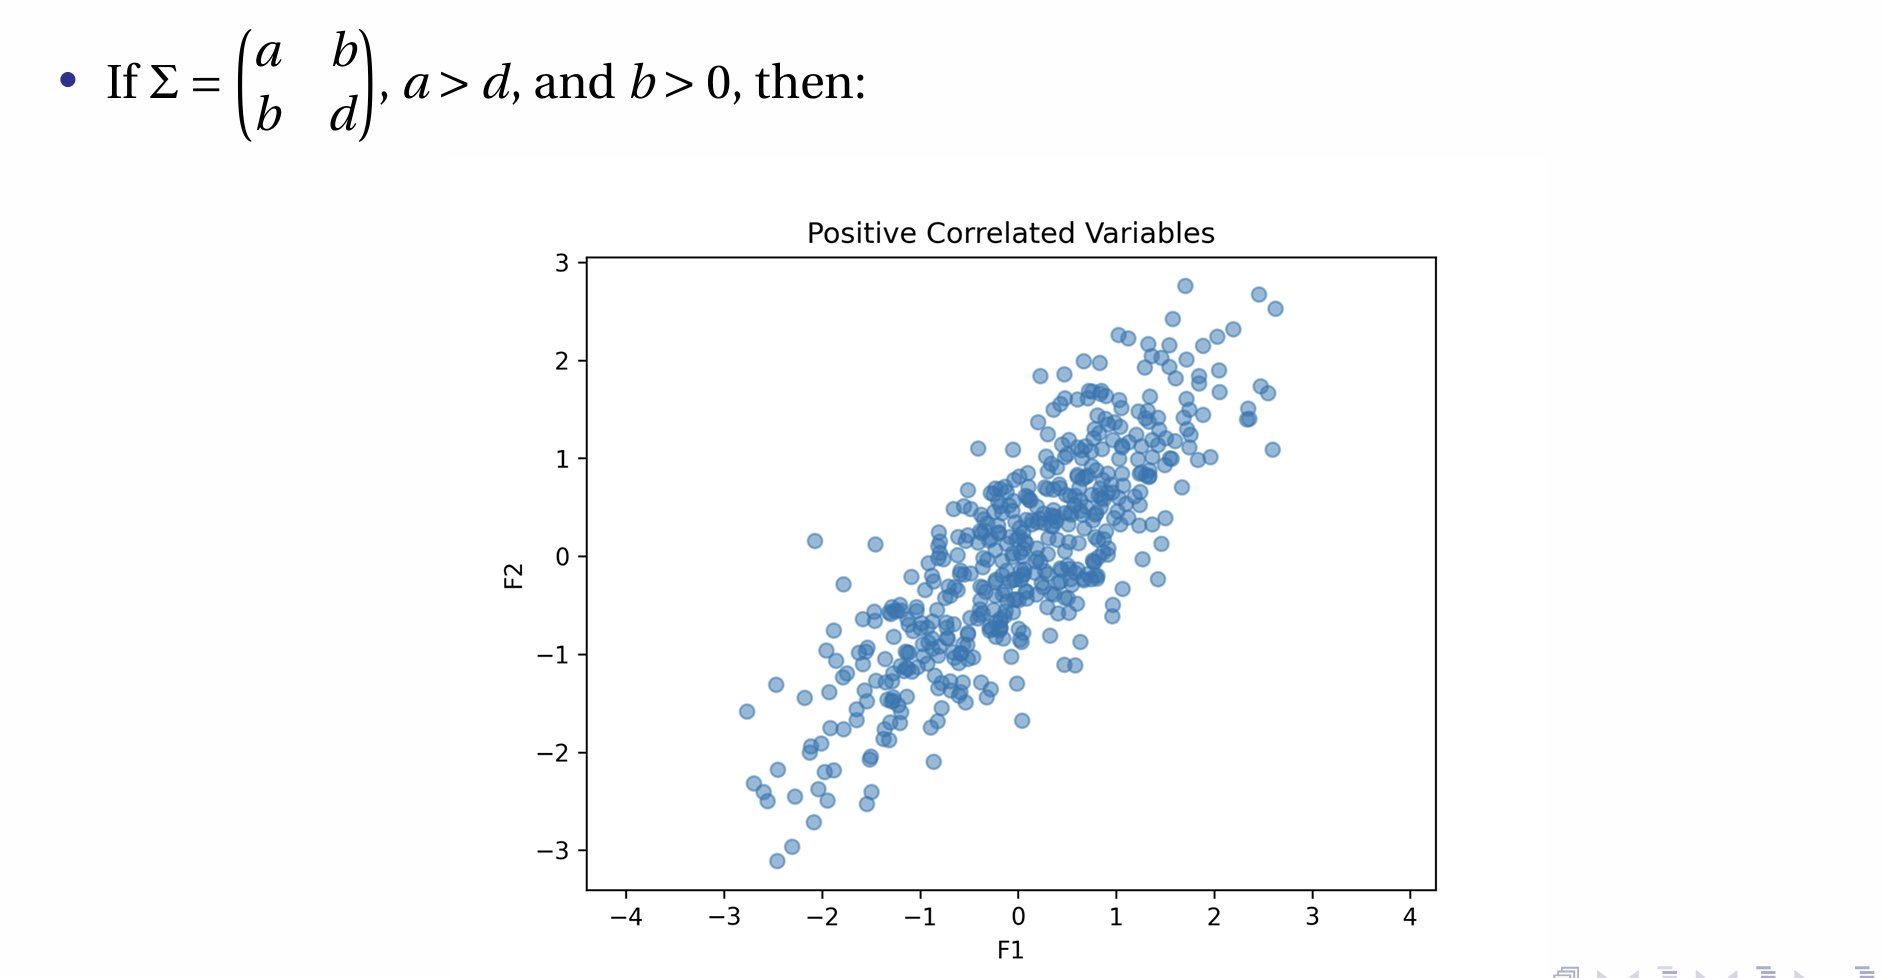
<center>Figure 9: Positive correlated variables, Adopted from [1]</center>
<br>

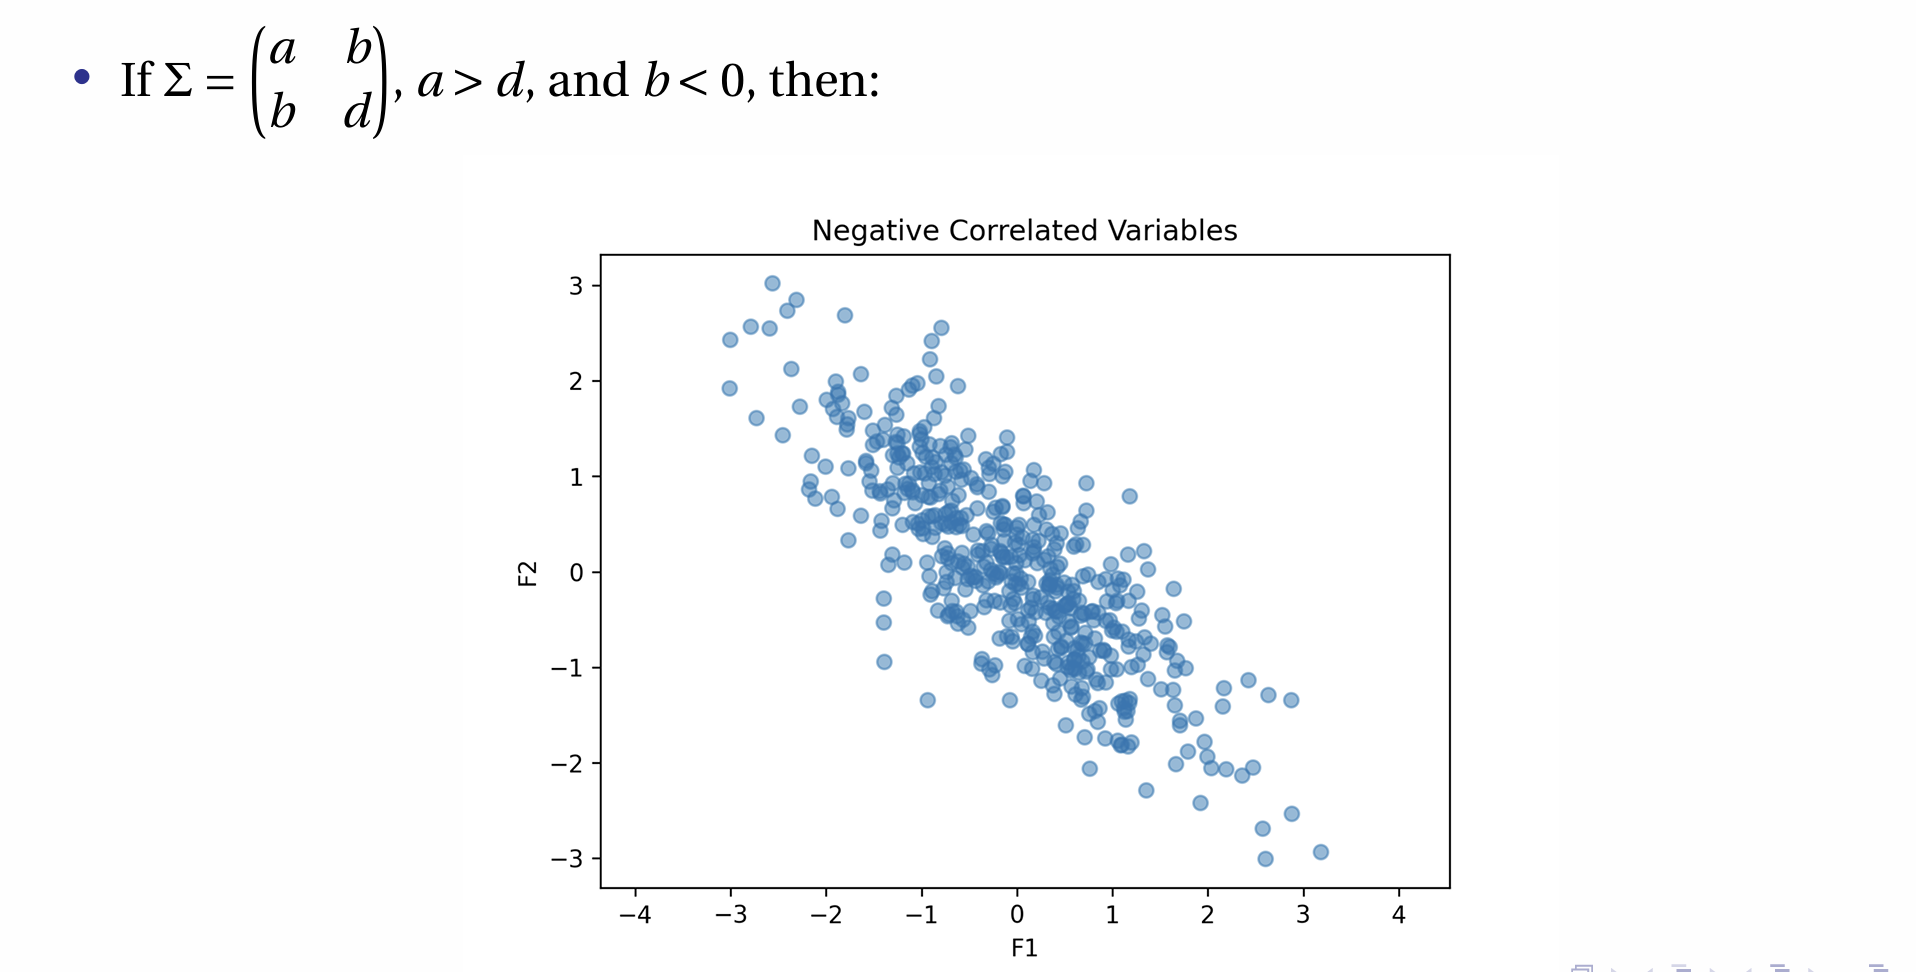
<center>Figure 10: Negative correlated variables, Adopted from [1]</center>
<br>

When we have the proper data we can obtain the covariance matrix theoratically. But  there are times when they give us a data or a subset of data and we can **estimate** covariance matrix:

+ Giiven *N* samples of *d* features, the sample covariance matrix $\Sigma$ is:

    $$\Sigma_{d \times d} = \frac{1}{N - 1} \sum_{i = 1}^{N} (X_i - \bar{X})(X_i - \bar{X})^T$$

+ Where $X_i$ is the *i-th* sample, and $\bar{X}_{d \times 1}$  is the mean of the sample.

For a better intuition see the below example:

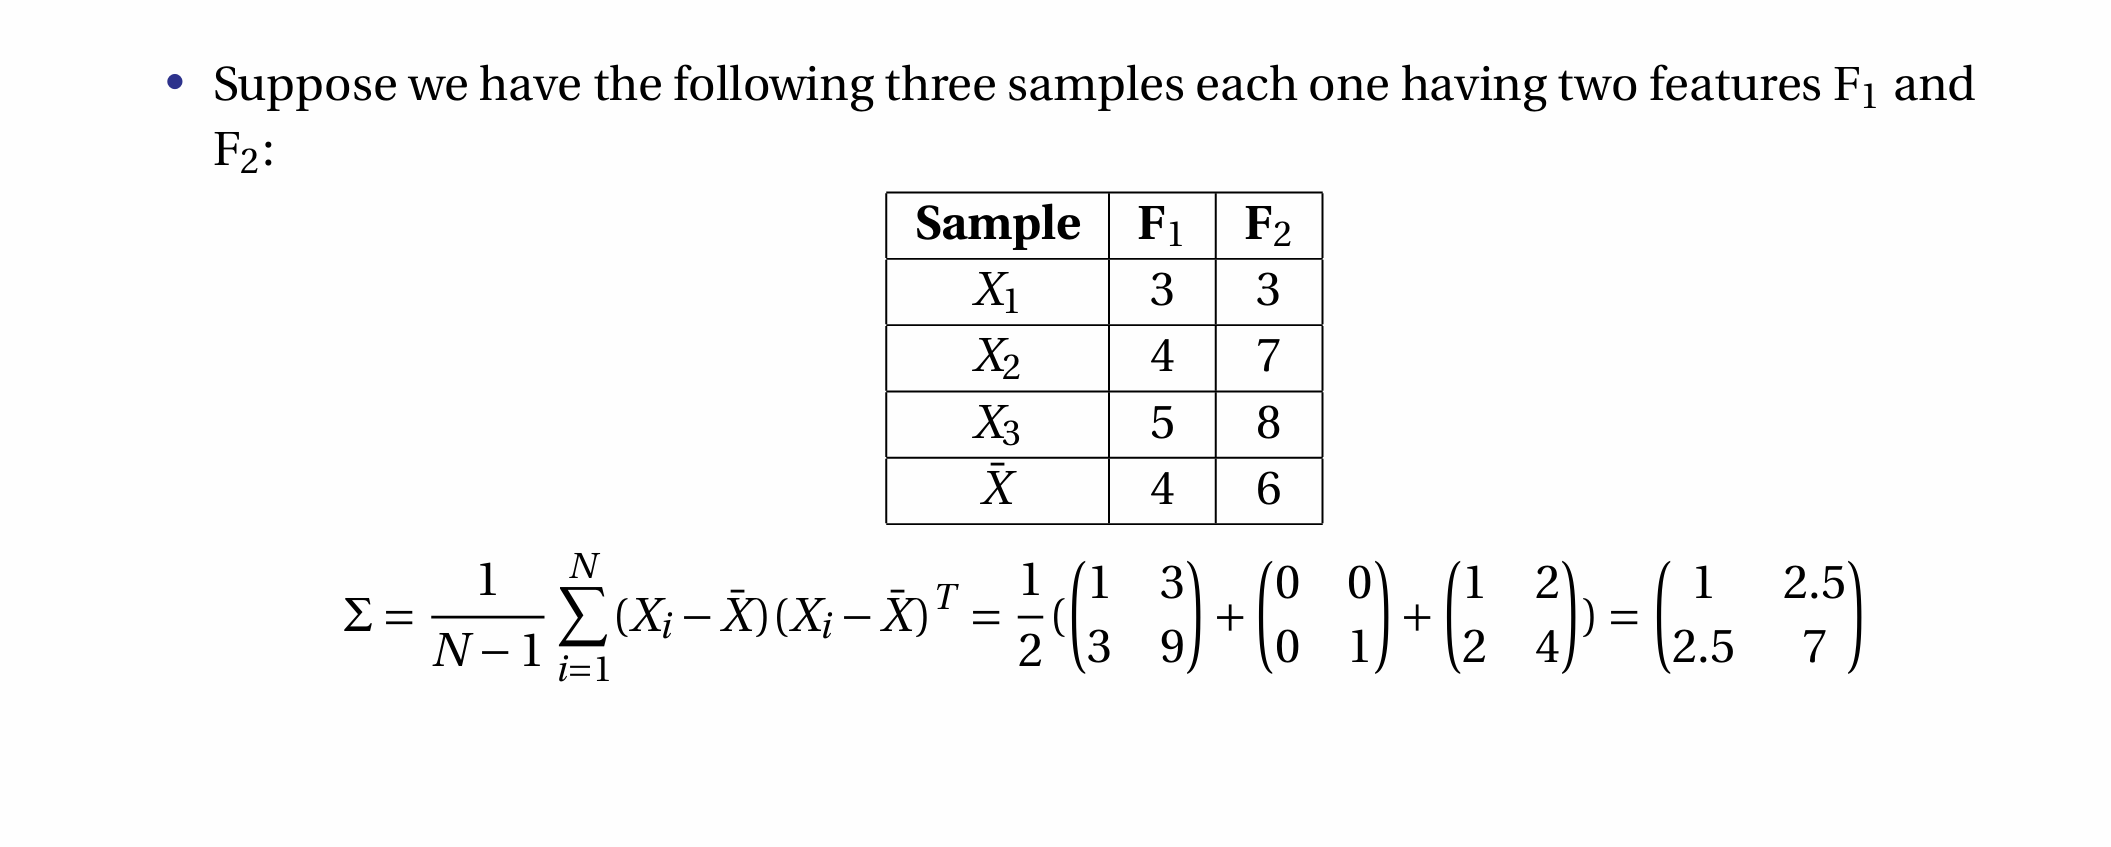
<center>Figure 11: An example of estimating covariance matrix, Adopted from [1]</center>
<br>

### Lagrange Multiplier

Lagrange multipliers is a method used in mathematical optimization to find the local maxima and minima of a function **subject to equality constraints**. It involves introducing auxiliary variables, called Lagrangian multipliers, to transform the constrained problem into an **uncostrained** one.<br>

The core problem idea is to optimize a function, say $f(x, y, z)$, with the added condition that certain equations, called constraints, must be satisfied.<br>
For example, We might want to find the largest volume of a box with a fixed surface area.<br>
The **constraints** are typically expressed as $g(x, y, z) = c$ where $c$ is a **constraint**.

Another example:<br>
We want to maximize $f(x)$ subject to $g(x) = 0$<br>
The optimal point occurs where the gradient of $f(x)$ is proportional to the gradient of $g(x)$ (i.e., they are aligned or in oppsite direction)

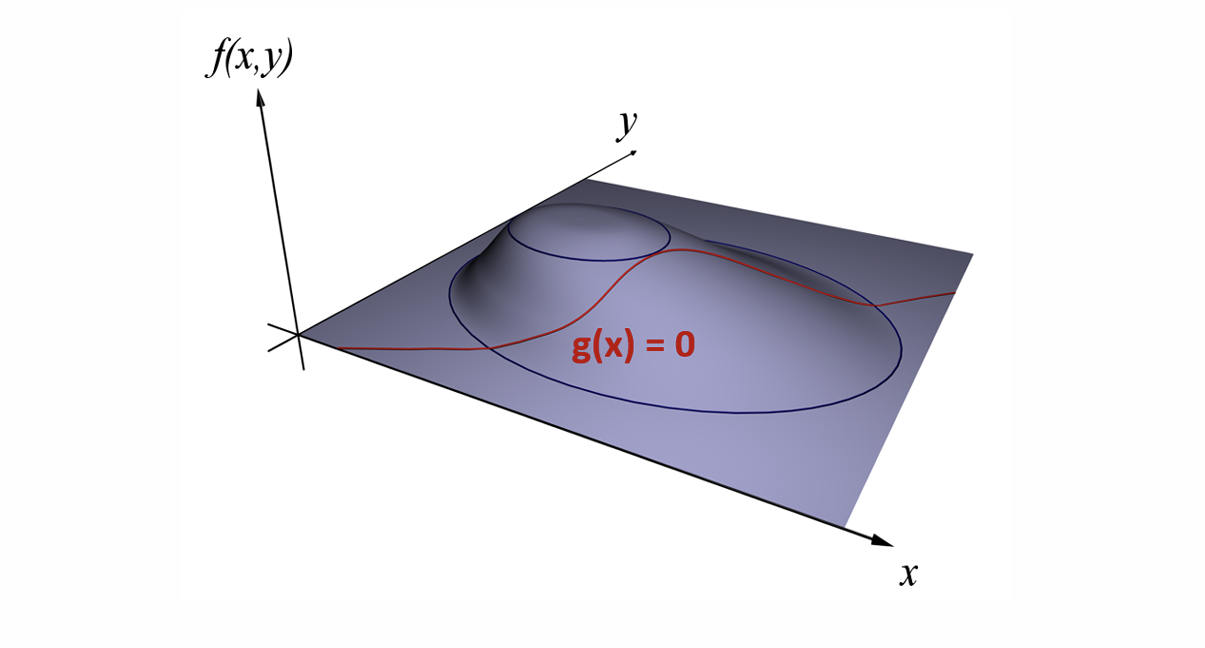
<center>Figure 12: Lagrange Multiplier example, Adopted from [1]</center>
<br>

We then combine the objective function and the constraint using the Lagrange Function:
$$\mathscr{L}(x, \lambda) = f(x) + \lambda g(x)$$

And then solve the system of equation:

$$\nabla \mathscr{L}(x, \lambda) = 0$$

+ $\mathscr{L}$ is a lagrangian 
+ $\lambda$ is langrangian multiplier
+ $g(x)$ is equality constraint
+ $f(x)$ is function.

Another example:

+ Maximize:

    $$f(x_1, x_2) = x_1 + x_2$$

+ Subject to:

    $$x_1^2 + x_2^2 = 1$$

+ Lagrangian: 

    $$L(x_1, x_2, \lambda) = x_1 + x_2 - \lambda (x_1^2 + x_2^2  - 1)$$

+ Partial derivation:

    $$\begin{cases} \frac{\partial L}{\partial x_1} = 1 - 2\lambda x_1 = 0 \\ \frac{\partial L}{\partial x_2} = 1 - 2\lambda x_2 = 0 \\ \frac{\partial L}{\lambda} = -(x_1^2 + x_2^2  - 1) = 0 \end{cases}$$

And the rest is:

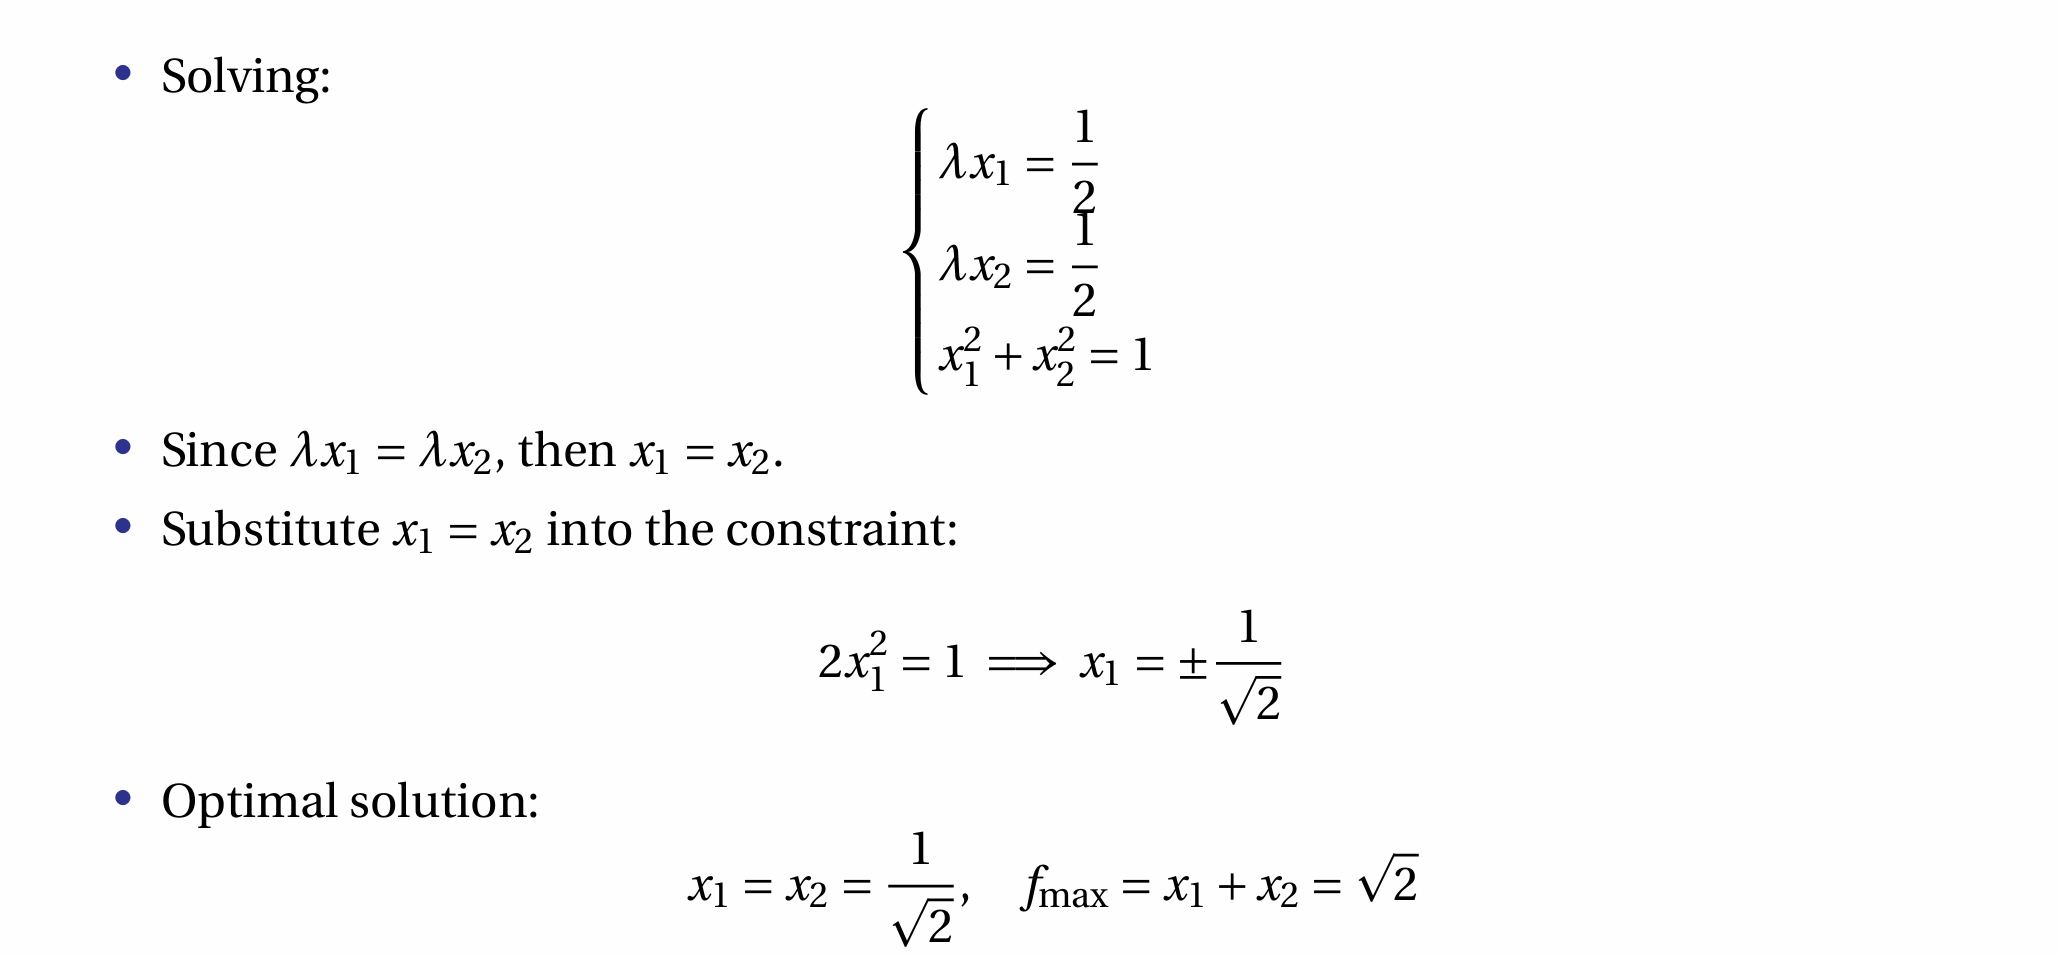
<center>Figure 13: final solution for the example above, Adopted from [1]</center>

+ The lagrange multiplier method can be extend to cases with more than one constraint. For constraints $g_1(x) = 0, g_2(x) = 0, ..., g_m(x) = 0$ The lagrangian becomes:


$$\mathscr{L}(x, \lambda_1, \lambda_2, ...) = f(x) - \lambda_1 g_1(x) -\lambda_2 g_2(x) - ...$$




Now let's get back to the our main problem PCA and use the above concepts on it:

+ The variance of the projected data onto the direction $v$ is: 
$$Var(Xv) = \frac{1}{n} \sum_{i=1}^{n}(x_i^Tv)^2$$

+ This can be written as:
    $$Var(Xv) = \frac{1}{n} ||Xv||^2 = \frac{1}{n} v^TX^TXv = v^T\Sigma v$$

    + $\frac{1}{n} X^TX = \Sigma$

+ We aim to maximize the variance $v^T \Sigma v$ under the constraint that $||v|| = 1$.
+ This lead to the following optimization problem:

$$\max_{v} v^T\Sigma v \;\;\;\;\;\; \text{ Subject To } \;\;\;\; ||v|| = 1$$

+ We introduce a Lagrange multiplier $\lambda$ and define the Lagrangian: 
$$L(v, \lambda) = v^T \Sigma v - \lambda(v^Tv - 1)$$

+ Taking the derivation with respect to $v$ and setting it to 0: 

$$\frac{\partial L}{\partial v} = 2\Sigma v - 2\lambda v = 0$$

+ This simplifies to:

$$\Sigma v = \lambda v$$

+ We define all $(v_1, \lambda_1), (v_2, \lambda_2), ..., (v_k, \lambda_k)$ as the *k* **eigenvectors** of $\Sigma$ having largest eigenvalues: $$\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_k$$.

+ The variance $v^T \Sigma v$ is maximized when *v* is the eigenvector corresponding to the largest eigenvalue of $\Sigma$.
+ The eigenvalue $\lambda$ represents the variance in the direction of the eigenvector $v$. 
+ Conclusion: Eigenvector of all covariance matrix maximize the variance of the projected data.

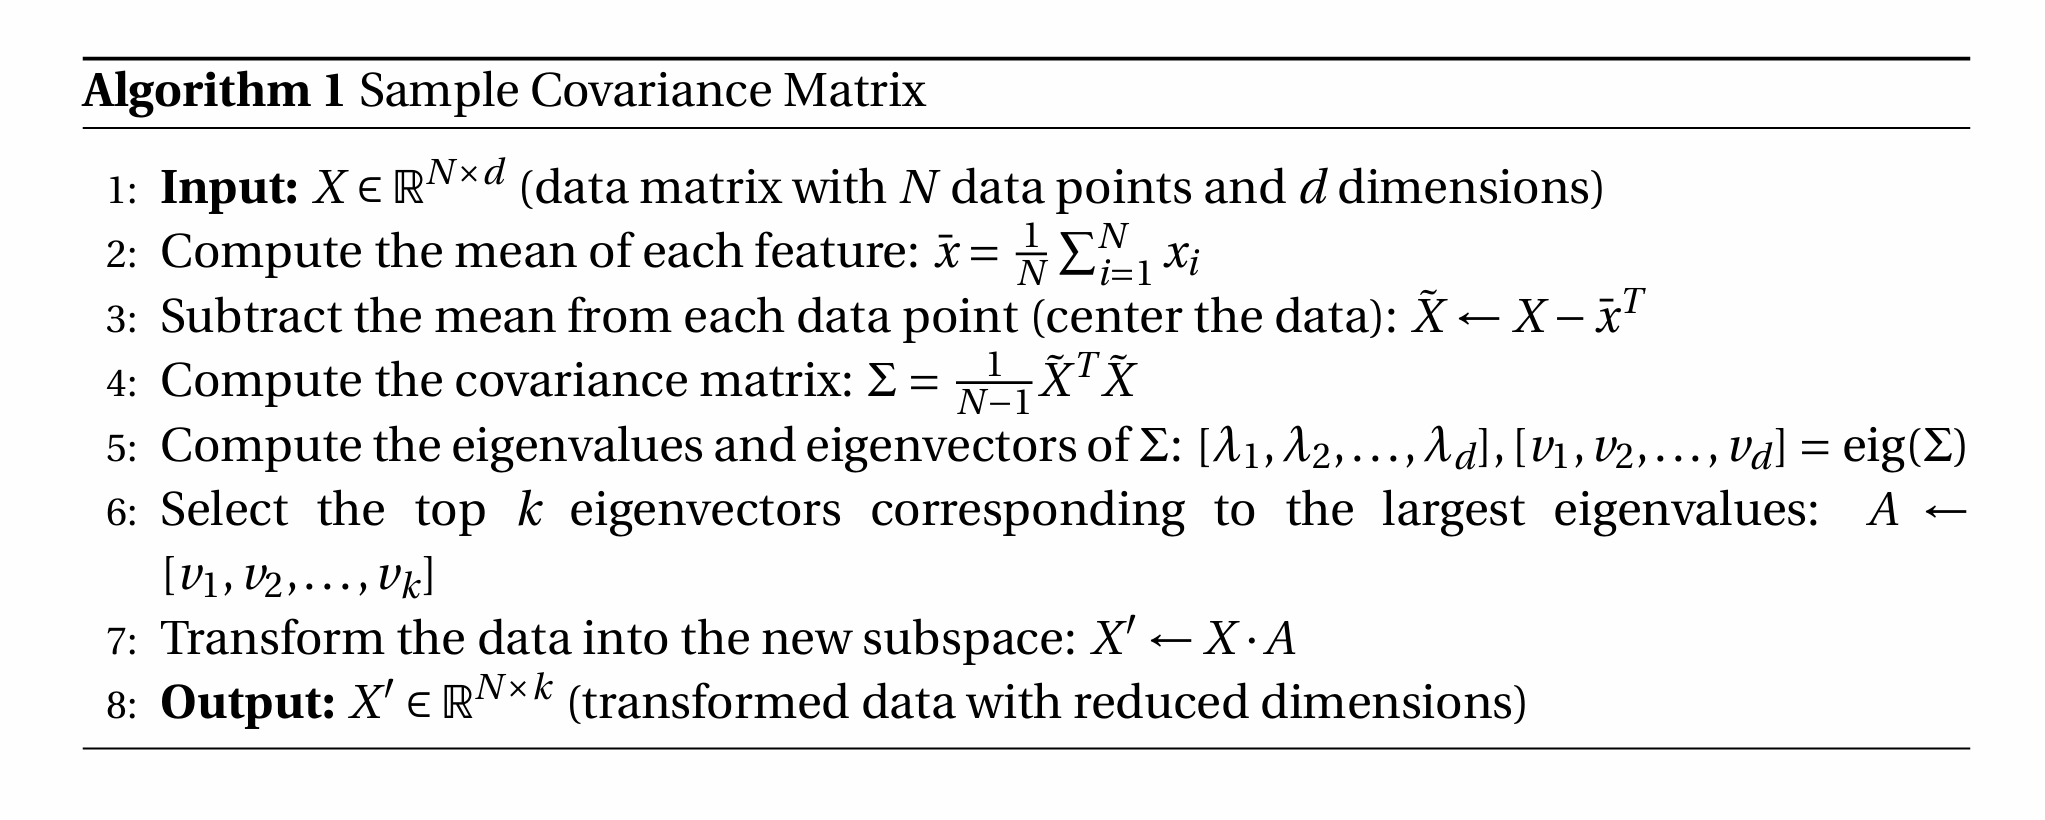
<center>Figure 14: Sample covariance matrix algorithm, Adopted from [1]</center>

### Number of principal components:

For *d* original dimensions, the sample covariance matrix $d \times d$, and has up to $d$ eigenvectors. So we can have up to $d$ principal components.<br>
Can ignore the components of lesser significance.

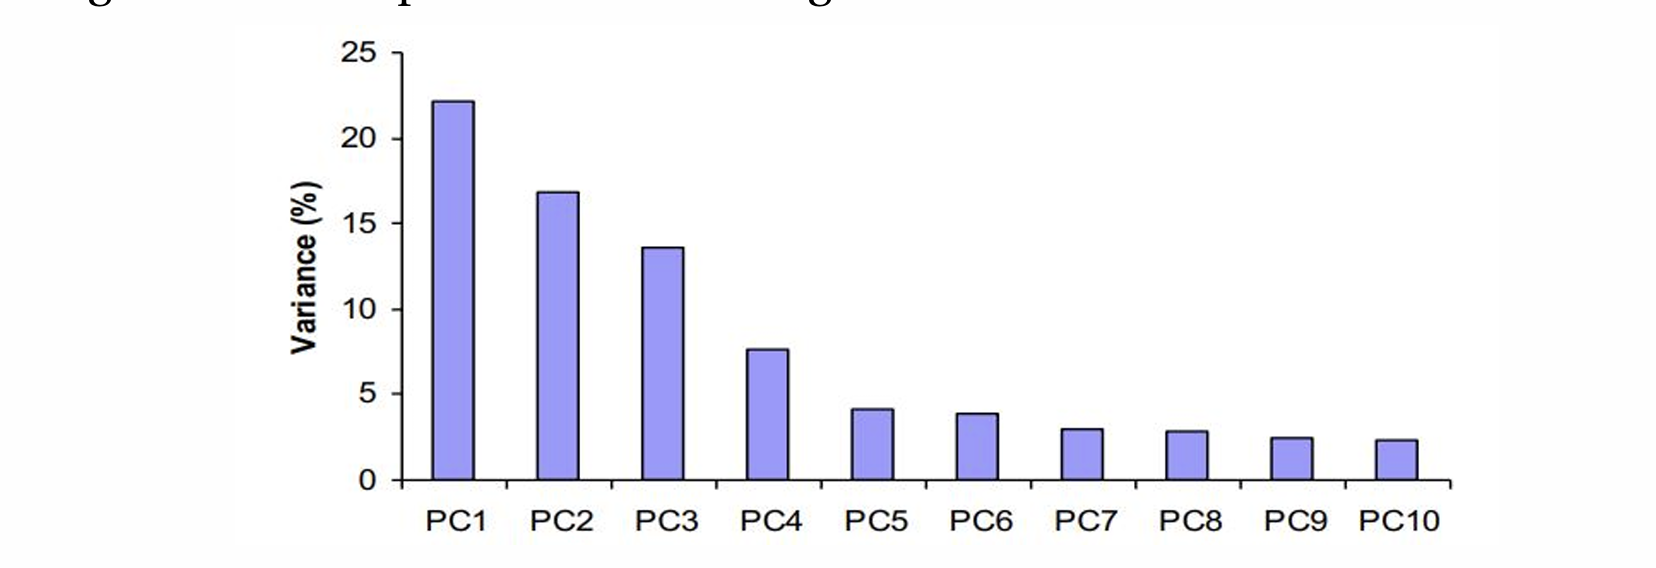
<center>Figure 15: The *i-th* PC's variance, Adopted from [1]</center>
<br>

> We lose some information, but if eigenvalues are small, we don't lose much.

Select the desired variance ratio and select the principal components:

$$\min_{k} \frac{\sum_{i = 1}^{k} \lambda_i}{\sum_{i=1}^{d} \lambda_i} \geq 0.9$$

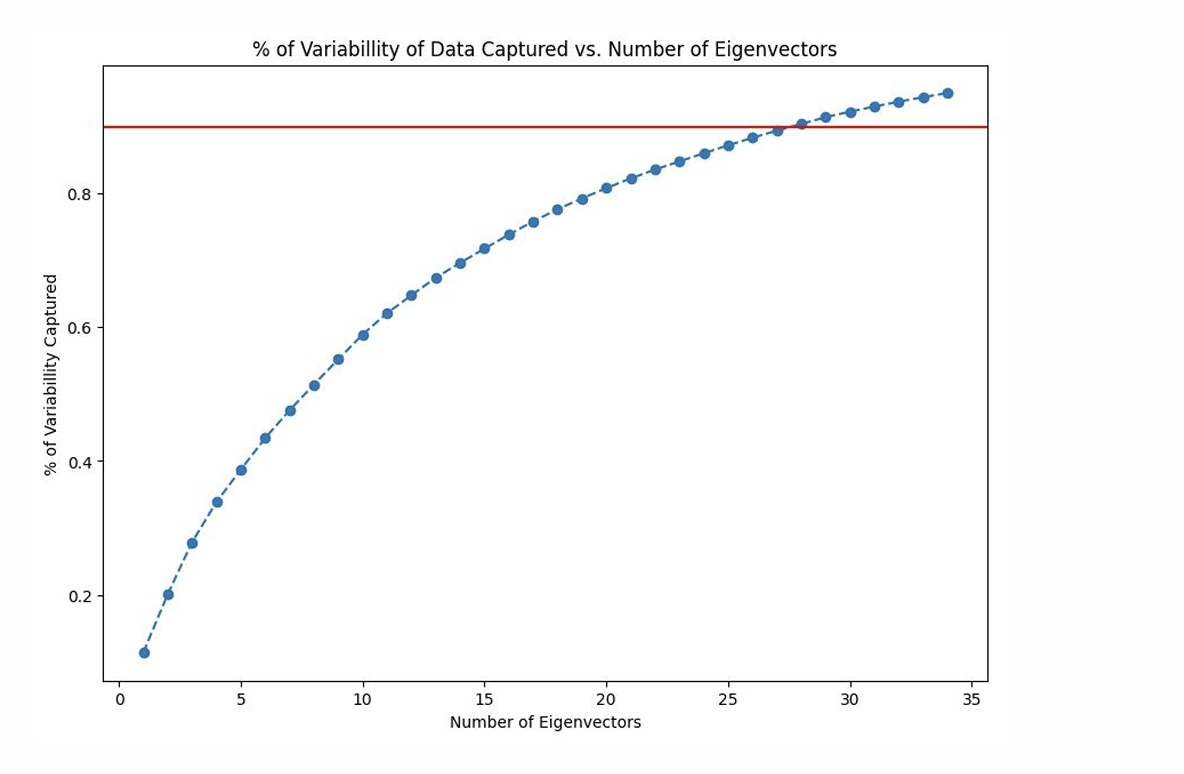
<center>Figure 15: percentage of data captured vs. number of eigenvectors.</center>

---

`There are other methods and more to PCA but left for later`

---

### References:
[1] [Dimensionality Reduction slides, ML course SU, Sharifi Zarchi](https://github.com/SharifiZarchi/Introduction_to_Machine_Learning/blob/main/Slides/Chapter_02_Unsupervised_Learning/02-Dimensionality%20Reduction/02-Dimensionality%20Reduction.pdf)<br>
[2] [Dimensionality Reduction, IBM](https://www.ibm.com/think/topics/dimensionality-reduction) <br>
[3] [Dimensionality Reduction: Principal Component Analysis, medium](https://medium.com/analytics-vidhya/dimensionality-reduction-principal-component-analysis-d1402b58feb1)<br>